# 工业增加值

GDP核算中的工业部分

工业包括：
1. 采矿业
2. 制造业（85%）
3. 电力、热力、燃气及水生产和供应业

**主要分析月度工业增加值**

## 月度工业增加值

- 由于资料不完整，只能采用推算方法
- 只统计规模以上（营收大于2000万）工业企业
- 不公布绝对值
- 剔除价格因素（不变价）

## 如何解读？

工业生产对经济景气程度更敏感。因为企业可以根据销售情况比较灵活的调整生产计划，不会有太强的时滞。其他行业的原材料和设备大多来自工业部门，其他产业的需求好转也将体现为工业生产加快。而工业生产加快，又会带动其他产业特别是生产性服务业的发展，如物流运输、研发设计、商务服务等。

### 总量分析
#### 需求影响

库存周期：

1. 生产不足，需求复苏，被动去库存 - 复苏期
2. 生产加快，主动补库存 - 繁荣期
3. 需求疲软，生产未及时调整，被动补库存 - 衰退期
4. 减少生产，主动去库存 - 萧条期

In [34]:
import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

In [35]:
# 工业增加值增长速度
gyzjzDf = ak.macro_china_nbs_nation(
    kind="月度数据", path="工业>工业增加值增长速度", period="2012-"
)
# 工业生产者出厂价格指数
ppiDf = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="价格指数>工业生产者出厂价格分类指数>工业生产者出厂价格指数(上年同月=100)",
    period="2012-",
)
# 投入产出表
# https://data.stats.gov.cn/files/html/quickSearch/tcc/trcc01.html
# 2020年投入产出表 https://data.stats.gov.cn/files/html/quickSearch/trcc/2012/2020.xlsx
inputOutputDf = pd.read_excel("/home/liao/various-data/data/2020.xlsx", header=4)

In [36]:
# 工业企业产成品存货
ccpDf2 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业产成品存货",
    period="2018-",
)
ccpDf2 = ccpDf2.transpose()
ccpDf2 = ccpDf2.iloc[::-1]

ccpDf1 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2012-2017)>工业企业产成品存货",
    period="2012-2017",
)
ccpDf1 = ccpDf1.transpose()
ccpDf1 = ccpDf1.iloc[::-1]

In [37]:
gyzjzRateDf1 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path=f"工业>工业分大类行业增加值增长速度(2012-2017)",
    period="2012-2017",
)
gyzjzRateDf2 = ak.macro_china_nbs_nation(
    kind="月度数据",
    path=f"工业>工业分大类行业增加值增长速度(2018-至今)",
    period="2018-",
)

In [38]:
gyzjzRateDf = pd.concat([gyzjzRateDf2, gyzjzRateDf1], axis=1)
gyzjzRateDf = gyzjzRateDf.transpose()
gyzjzRateDf = gyzjzRateDf.iloc[::-1]

In [39]:
# 行业分类
f = open("/home/liao/various-data/data/国民经济行业分类_2017.json", "r")
cotnent = f.read()
hyflJson = json.loads(cotnent)
# 二级分类
hyfl = {
    "codeToName": {},
    "nameToCode": {},
}
for item in hyflJson:
    for child in item["children"]:
        hyfl["codeToName"][child["code"]] = child["name"]
        hyfl["nameToCode"][child["name"]] = child["code"]

In [40]:
# gyzjzDf
gyzjzDf = gyzjzDf.transpose()
gyzjzDf = gyzjzDf.iloc[::-1]

# ppiDf
ppiDf = ppiDf.transpose()
ppiDf = ppiDf.iloc[::-1]

In [41]:
ccpDf = pd.concat([ccpDf1, ccpDf2])

In [42]:
gyzjzSeries = gyzjzDf["工业增加值_累计增长(%)"]
ppiSeries = ppiDf["工业生产者出厂价格指数(上年同月=100)"] - 100
ccpSeries = ccpDf["工业企业产成品存货_增减(%)"]

产成品存货是名义值，用“工业增加值同比+PPI同比”来指代名义工业增加值增速

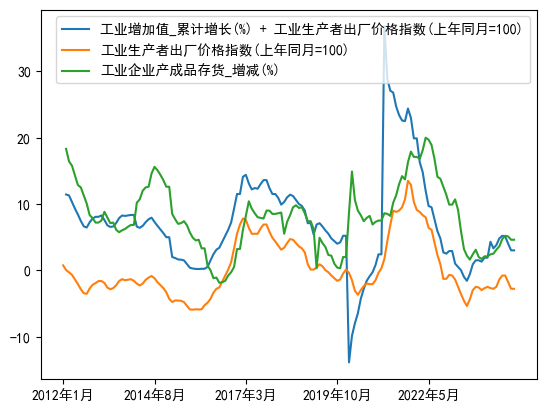

In [43]:
s1 = (gyzjzSeries + ppiSeries).ffill()
s2 = ccpSeries.ffill()
s3 = ppiSeries.ffill()
xtricks = range(0, s1.size, round(s1.size / 5))

fig = plt.figure()
ax = fig.gca()
ax.set_xticks(xtricks)
ax.plot(
    s1.index, s1, label="工业增加值_累计增长(%) + 工业生产者出厂价格指数(上年同月=100)"
)
ax.plot(s3.index, s3, label="工业生产者出厂价格指数(上年同月=100)")
ax.plot(s2.index, s2, label="工业企业产成品存货_增减(%)")
plt.legend()

ppi为负，名义工业增加值增速下降，但是存货增速没有下降，显示需求很低。

#### 价格影响

出场价格上涨，会提高企业盈利水平，从而带动工业生产

可以用ppi指代价格水平

#### 流动性影响

当流动性宽松的时候：1. 企业更容易融资；2. 刺激社会需求

用社会融资增速做对比分析

### 结构分析

#### 各工业行业的增加值占比

- 数据从投入产出表推算得到

In [44]:
rows = inputOutputDf[6:103]

total = 0
names = []
codes = []
for idx, row in rows.iterrows():
    total += row[-2]
    names.append(row[1])
    codes.append(row[2])

gyzjzRatioByIndustrySeries = pd.Series(
    [row[-2] / total for idx, row in rows.iterrows()], [names, codes]
)


def groupByCode(code):
    return code[1][0:2]


# gyzjzRatioByIndustrySeries.sort_values(ascending=False).head(10)
# 工业增加值分行业占比
gyzjzzb = (
    gyzjzRatioByIndustrySeries.groupby(by=groupByCode)
    .sum()
    .sort_values(ascending=False)
)
for i in range(10):
    print(gyzjzzb[i] * 100, gyzjzzb.index[i], hyfl["codeToName"][gyzjzzb.index[i]])

26.067240543325664 39 计算机、通信和其他电子设备制造业
10.570067226743506 07 石油和天然气开采业
8.85273949965298 26 化学原料和化学制品制造业
6.3885079808455885 08 黑色金属矿采选业
4.308127120747493 35 专用设备制造业
4.172536756521664 13 农副食品加工业
4.031956945853113 34 通用设备制造业
3.9774082516398237 32 有色金属冶炼和压延加工业
3.7488480892513136 36 汽车制造业
3.6692111408970107 38 电气机械和器材制造业


/tmp/ipykernel_5518/2542565388.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total += row[-2]
/tmp/ipykernel_5518/2542565388.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  names.append(row[1])
/tmp/ipykernel_5518/2542565388.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  codes.append(row[2])
/tmp/ipykernel_5518/2542565388.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future ve

20年相对于17年变化巨大，计算机、通信和其他电子设备制造业跃升到第一，占比达到26%。

#### 关注重要行业（占比高）以及月度异常值

#### 按照各种维度合并分析

##### 出口依赖型

工业交货值占营收比重，可以用来判断某行业的出口依赖程度。超过10%的行业可以定义为高出口依赖型行业。

根据2019年数据推算出15个高出口依赖型行业：

1. 计算机、通信和其他电子设备制造业
2. 金属制品、机械和设备修理业
3. 其他制造业
4. 文教、工美、体育和娱乐用品制造业
5. 皮革、毛皮、羽毛及其制品和制鞋业
6. 家具制作业
7. 纺织服装、服饰业
8. 铁路、船舶、航空航天和其他运输设备制造业
9. 电气机械及器材制造业
10. 仪器仪表制造业
11. 橡胶和塑料制品业
12. 通用设备制造业
13. 纺织业
14. 专用设备制造业
15. 金属制品业

In [61]:
industries1 = [
    "计算机、通信和其他电子设备制造业",
    "金属制品、机械和设备修理业",
    "其他制造业",
    "文教、工美、体育和娱乐用品制造业",
    "皮革、毛皮、羽毛及其制品和制鞋业",
    "家具制造业",
    "纺织服装、服饰业",
    "铁路、船舶、航空航天和其他运输设备制造业",
    "电气机械和器材制造业",
    "仪器仪表制造业",
    "橡胶和塑料制品业",
    "通用设备制造业",
    "纺织业",
    "专用设备制造业",
    "金属制品业",
]

industries2 = []
for key in gyzjzzb.keys():
    if hyfl["codeToName"][key] not in industries1:
        industries2.append(hyfl["codeToName"][key])


def groupExport(code):
    if hyfl["codeToName"][code] in industries1:
        return 1
    else:
        return 0


exportIndustryRatio = gyzjzzb.groupby(groupExport).sum()
ratios1 = pd.Series(
    [
        gyzjzzb[hyfl["nameToCode"][item]] / exportIndustryRatio[1]
        for item in industries1
    ],
    index=industries1,
)
ratios2 = pd.Series(
    [
        gyzjzzb[hyfl["nameToCode"][item]] / exportIndustryRatio[0]
        for item in industries2
    ],
    index=industries2,
)

m1 = gyzjzRateDf[[f"{item}增加值_同比增长(%)" for item in industries1]].ffill()

# Not only must the shapes of x and y be correct, 
# but also the column names of x must match the index names of y. 
# Otherwise this code in pandas/core/frame.py will raise a ValueError:
# m1.columns, ratios1.index
# m1.dot(ratios1)
rr = pd.Series(np.dot(m1, ratios1))

m2 = gyzjzRateDf[[f"{item}增加值_同比增长(%)" for item in industries2]].ffill()
rr2 = pd.Series(np.dot(m2, ratios2))


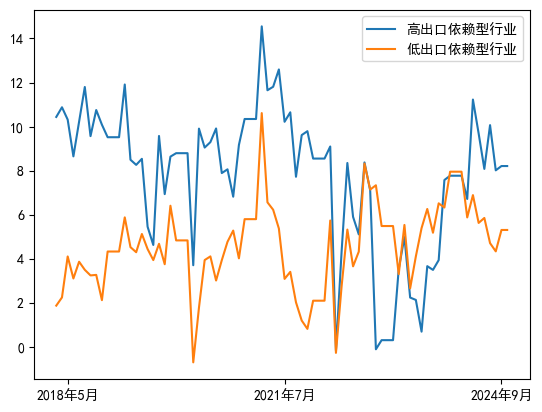

In [62]:
fig = plt.figure()
ax = fig.gca()
tricks = range(0, len(m1.index), round(len(m1.index) / 4))
ax.set_xticks(tricks)
ax.plot(m1.index, rr, label="高出口依赖型行业")
ax.plot(m2.index, rr2, label="低出口依赖型行业")
plt.legend()

##### 上中下游

上游：

- 黑色金属矿采选业
- 有色金属矿采选业
- 煤炭开采和洗选业
- 石油和天然气开采业
- 非金属矿采选业

中游：

- 黑色金属冶炼和压延加工业
- 有色金属冶炼和压延加工业
- 石油、煤炭及其他燃料加工业
- 非金属矿物制品业
- 金属制品业
- 橡胶和塑料制品业
- 化学原料和化学制品制造业
- 化学纤维制造业
- 计算机、通信和其他电子设备制造业
- 造纸和纸制品业
- 仪器仪表制造业
- 电气机械和器材制造业
- 专用设备制造业
- 通用设备制造业

下游：

- 汽车制造业
- 铁路、船舶、航空航天和其他运输设备制造业
- 木材加工和木、竹、藤、棕、草制品业
- 家具制造业
- 农副食品加工业
- 食品制造业
- 烟草制品业
- 酒、饮料和精制茶制造业
- 印刷和记录媒介复制业
- 医药制造业
- 纺织业
- 纺织服装、服饰业
- 皮革、毛皮、羽毛及其制品和制鞋业
- 文教、工美、体育和娱乐用品制造业

##### 新旧动能